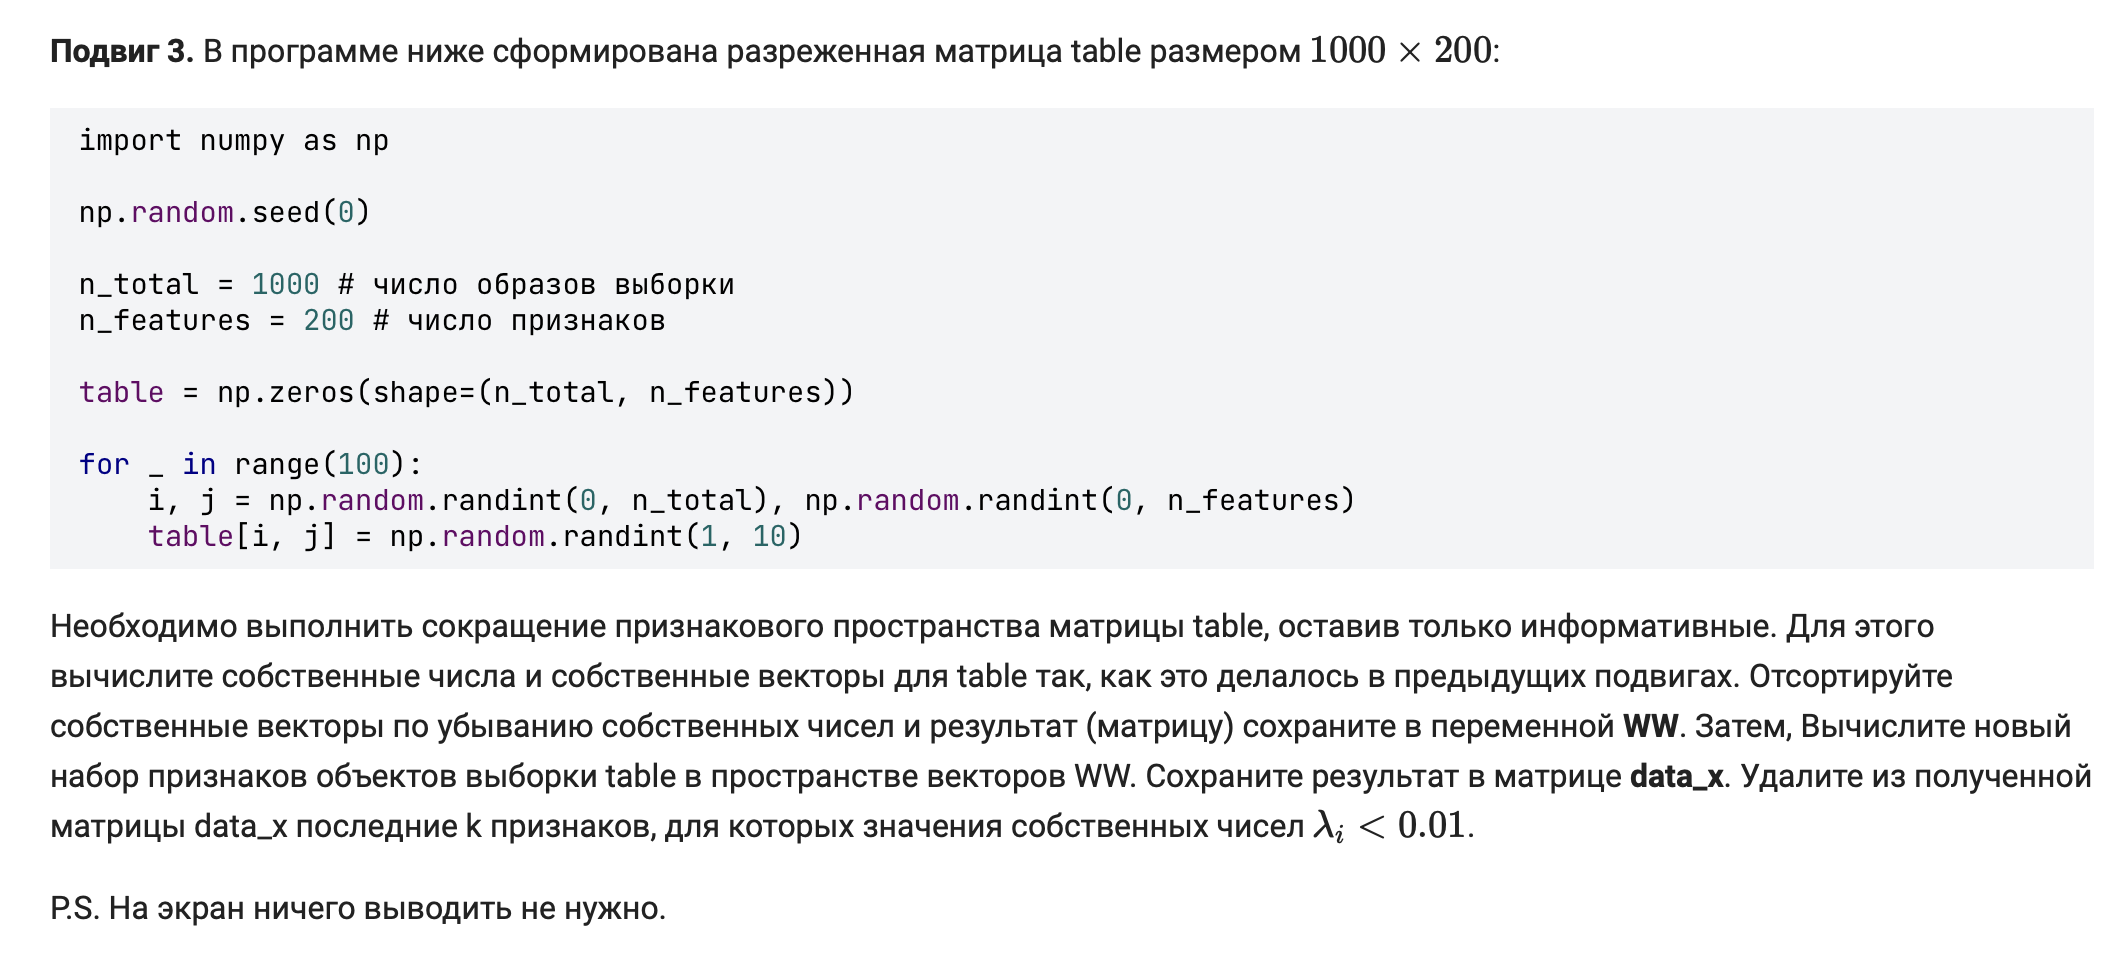

In [29]:
import numpy as np

np.random.seed(0)

n_total = 1000 # число образов выборки
n_features = 200 # число признаков

table = np.zeros(shape=(n_total, n_features))

for _ in range(100):
    i, j = np.random.randint(0, n_total), np.random.randint(0, n_features)
    table[i, j] = np.random.randint(1, 10)

# матрицу table не менять
F = 1/n_total * table.T @ table
L, W = np.linalg.eig(F)
WW = W[:, np.argsort(-L)]
data_x = table @ WW
data_x = data_x[:, :(L > 0.01).sum()]
data_x.shape

(1000, 52)

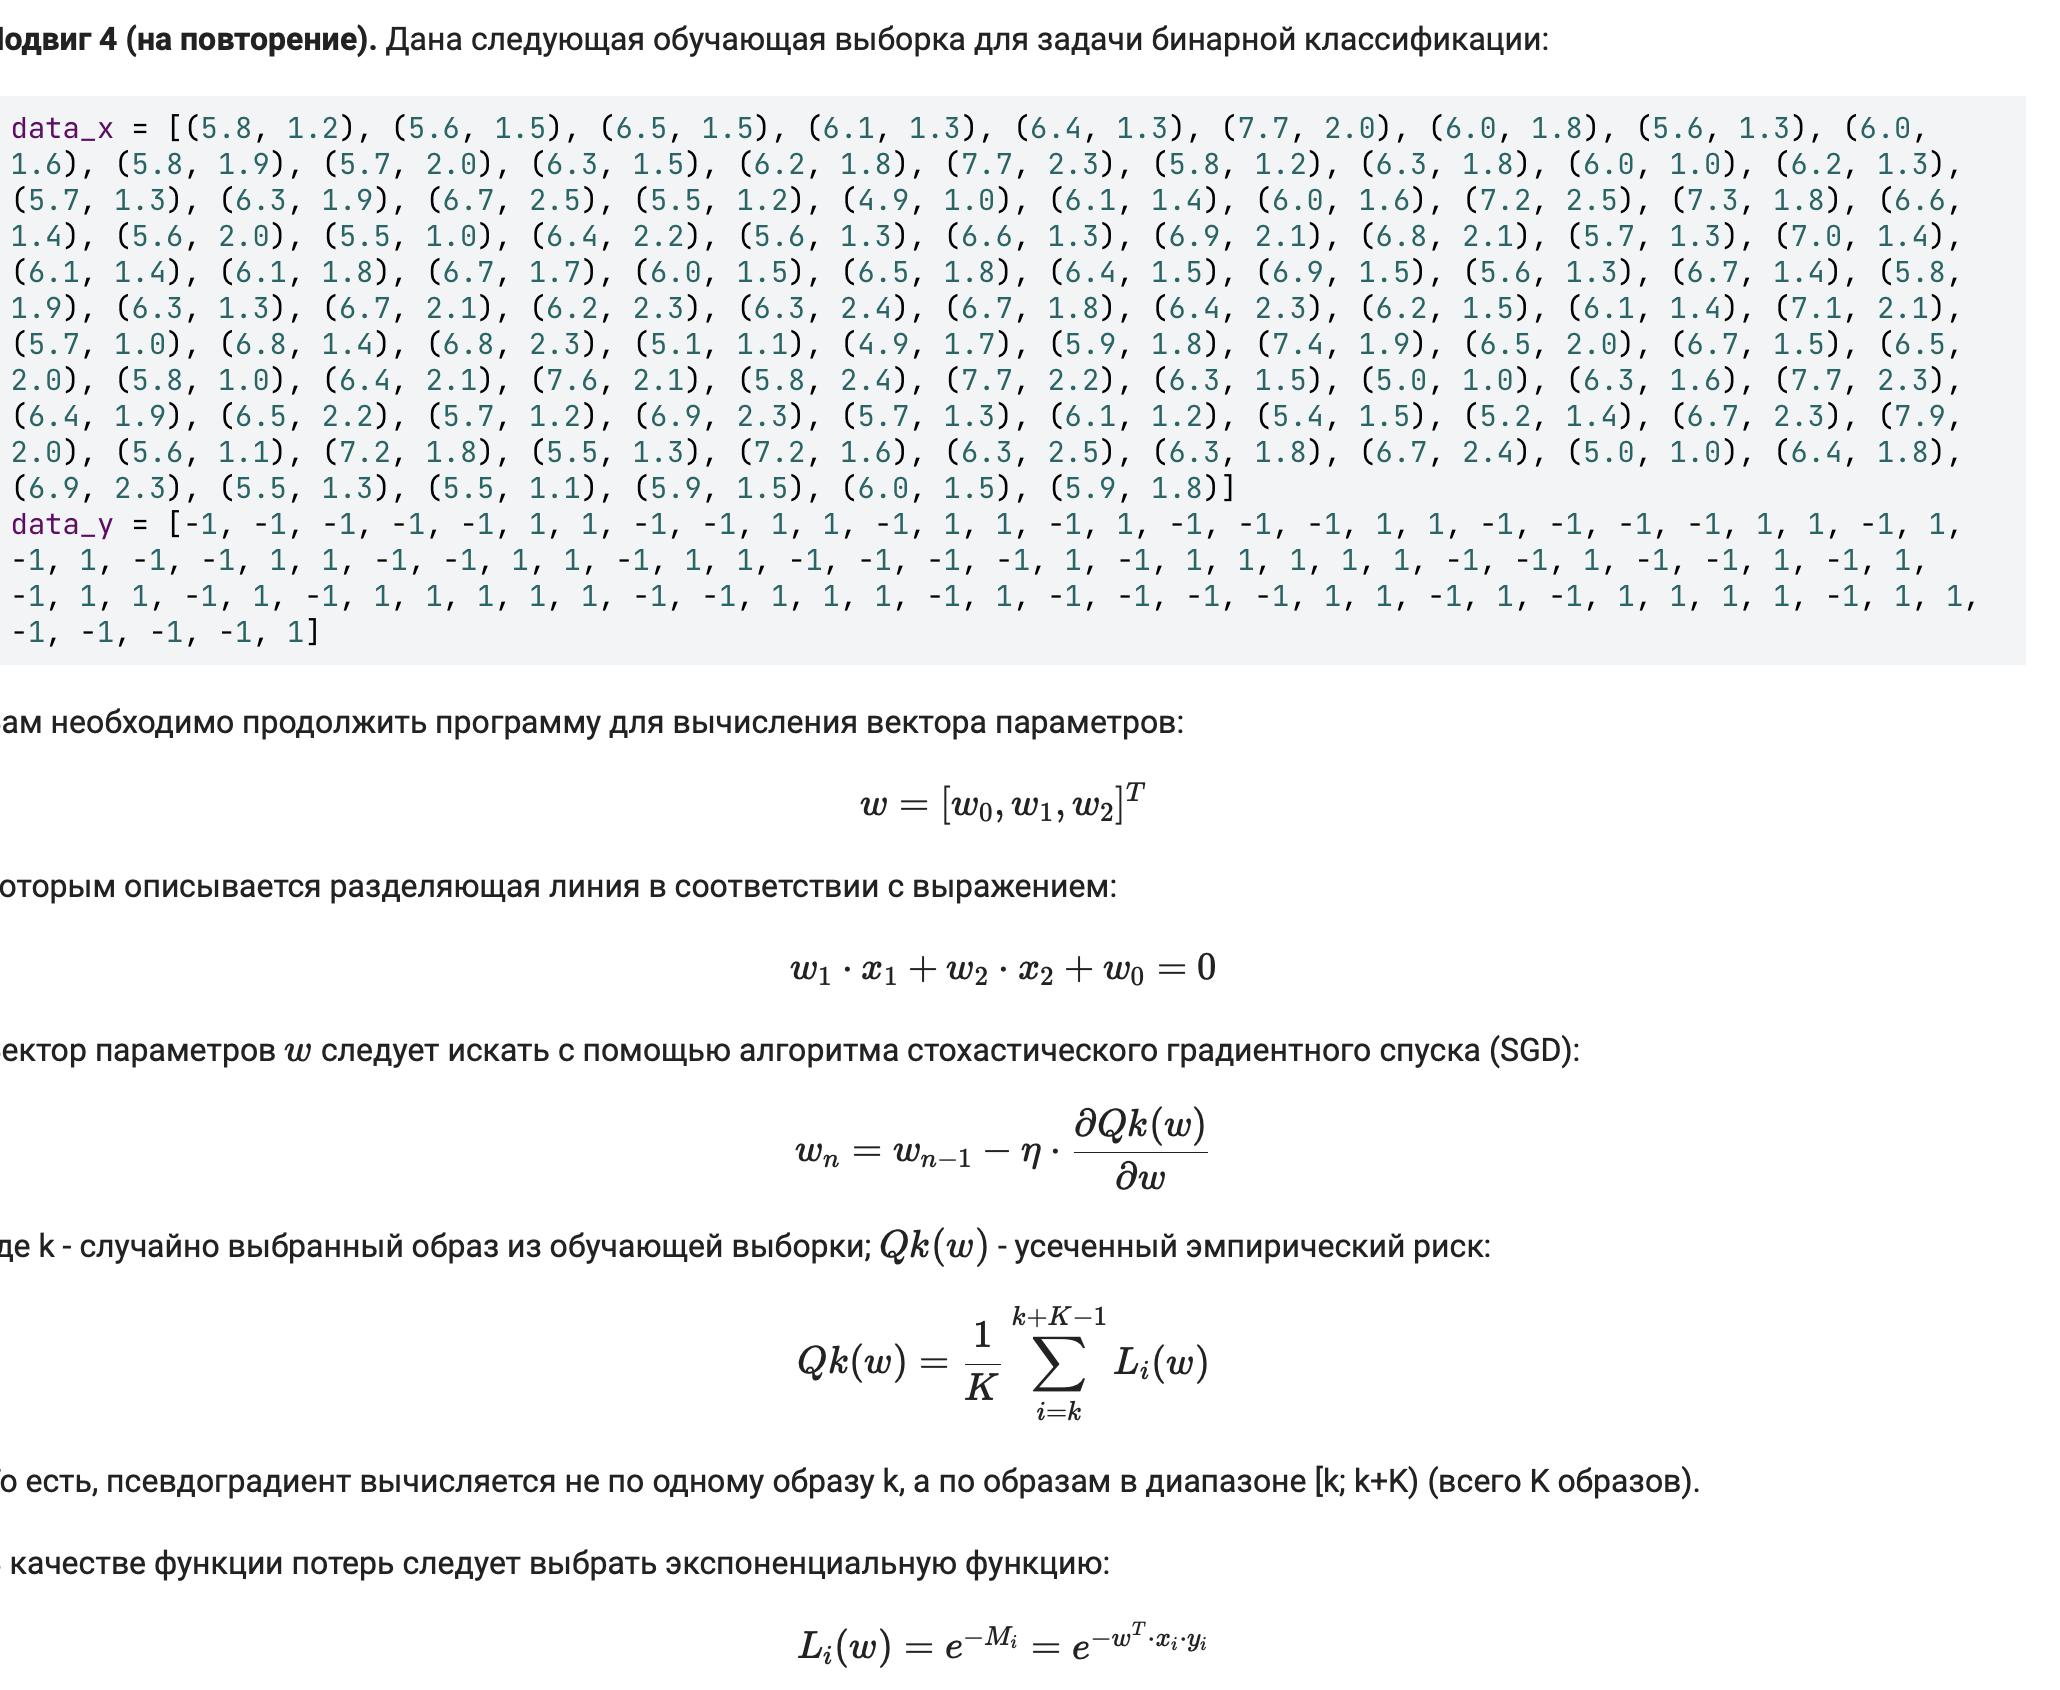
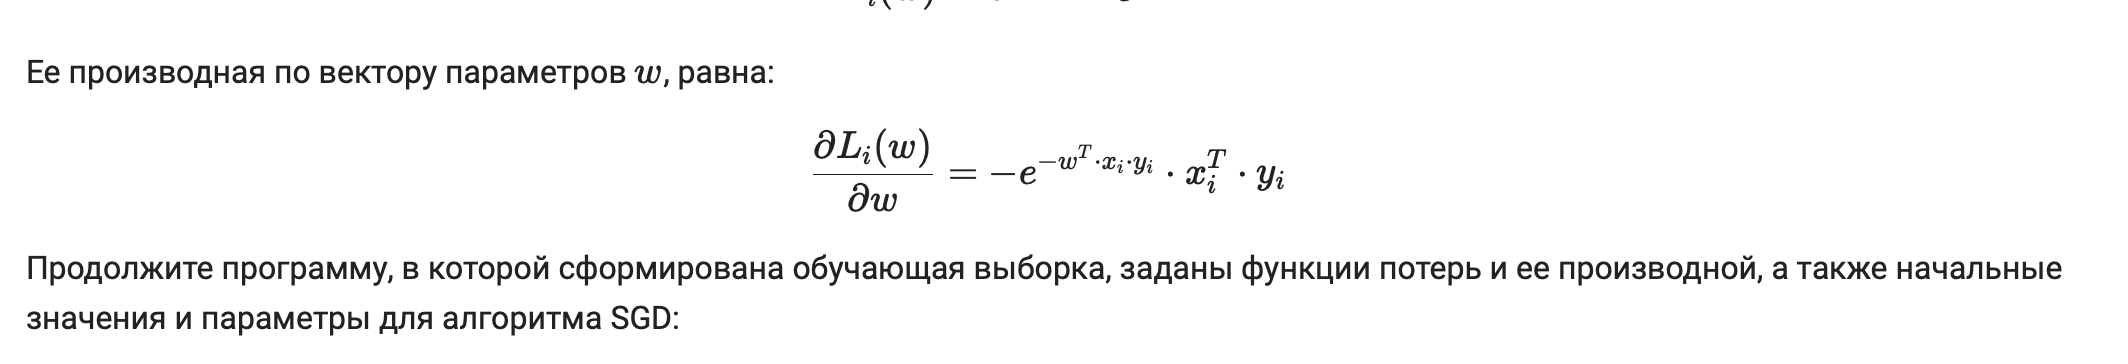
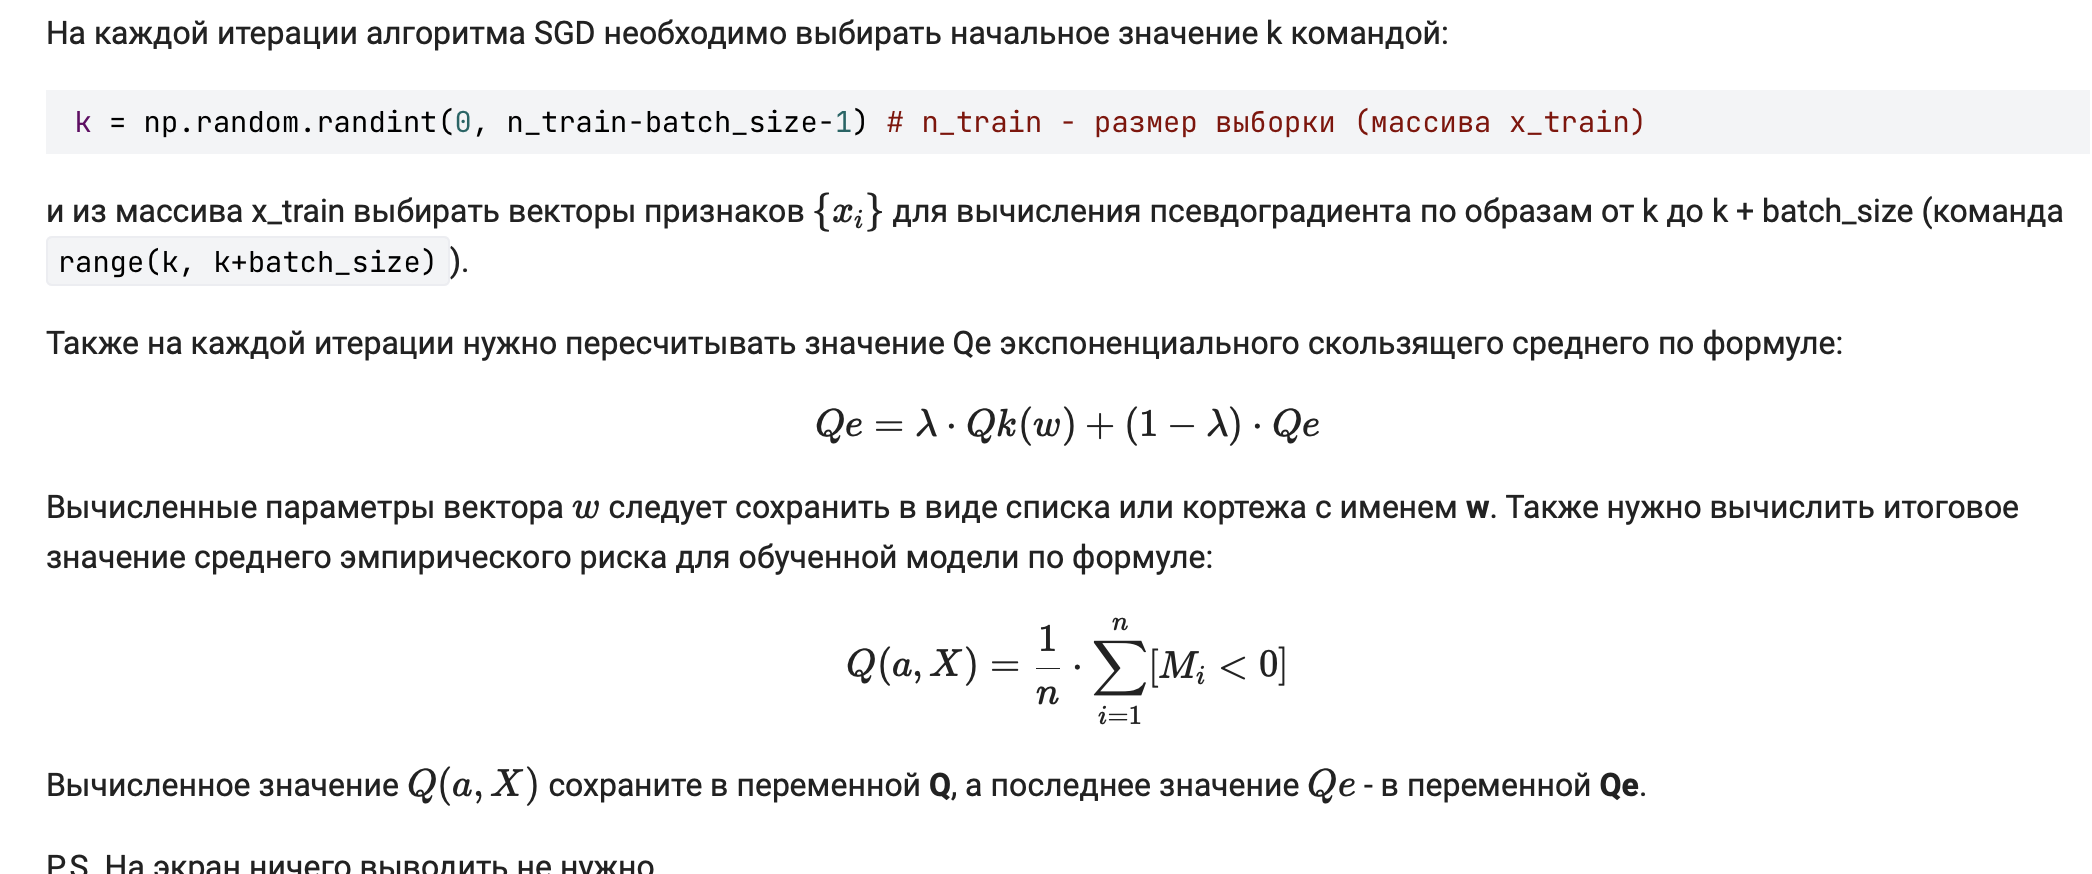

In [48]:
import numpy as np


# экспоненциальная функция потерь
def loss(w, x, y):
    M = np.dot(w, x.T) * y
    return np.exp(-M)


# производная экспоненциальной функции потерь по вектору w
def df(w, x, y):
    M = np.dot(w, x.T) * y
    return -np.exp(-M) * y @ x


data_x = [(5.8, 1.2), (5.6, 1.5), (6.5, 1.5), (6.1, 1.3), (6.4, 1.3), (7.7, 2.0), (6.0, 1.8), (5.6, 1.3), (6.0, 1.6), (5.8, 1.9), (5.7, 2.0), (6.3, 1.5), (6.2, 1.8), (7.7, 2.3), (5.8, 1.2), (6.3, 1.8), (6.0, 1.0), (6.2, 1.3), (5.7, 1.3), (6.3, 1.9), (6.7, 2.5), (5.5, 1.2), (4.9, 1.0), (6.1, 1.4), (6.0, 1.6), (7.2, 2.5), (7.3, 1.8), (6.6, 1.4), (5.6, 2.0), (5.5, 1.0), (6.4, 2.2), (5.6, 1.3), (6.6, 1.3), (6.9, 2.1), (6.8, 2.1), (5.7, 1.3), (7.0, 1.4), (6.1, 1.4), (6.1, 1.8), (6.7, 1.7), (6.0, 1.5), (6.5, 1.8), (6.4, 1.5), (6.9, 1.5), (5.6, 1.3), (6.7, 1.4), (5.8, 1.9), (6.3, 1.3), (6.7, 2.1), (6.2, 2.3), (6.3, 2.4), (6.7, 1.8), (6.4, 2.3), (6.2, 1.5), (6.1, 1.4), (7.1, 2.1), (5.7, 1.0), (6.8, 1.4), (6.8, 2.3), (5.1, 1.1), (4.9, 1.7), (5.9, 1.8), (7.4, 1.9), (6.5, 2.0), (6.7, 1.5), (6.5, 2.0), (5.8, 1.0), (6.4, 2.1), (7.6, 2.1), (5.8, 2.4), (7.7, 2.2), (6.3, 1.5), (5.0, 1.0), (6.3, 1.6), (7.7, 2.3), (6.4, 1.9), (6.5, 2.2), (5.7, 1.2), (6.9, 2.3), (5.7, 1.3), (6.1, 1.2), (5.4, 1.5), (5.2, 1.4), (6.7, 2.3), (7.9, 2.0), (5.6, 1.1), (7.2, 1.8), (5.5, 1.3), (7.2, 1.6), (6.3, 2.5), (6.3, 1.8), (6.7, 2.4), (5.0, 1.0), (6.4, 1.8), (6.9, 2.3), (5.5, 1.3), (5.5, 1.1), (5.9, 1.5), (6.0, 1.5), (5.9, 1.8)]
data_y = [-1, -1, -1, -1, -1, 1, 1, -1, -1, 1, 1, -1, 1, 1, -1, 1, -1, -1, -1, 1, 1, -1, -1, -1, -1, 1, 1, -1, 1, -1, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, 1, 1, -1, -1, -1, -1, 1, -1, 1, 1, 1, 1, 1, -1, -1, 1, -1, -1, 1, -1, 1, -1, 1, 1, -1, 1, -1, 1, 1, 1, 1, 1, -1, -1, 1, 1, 1, -1, 1, -1, -1, -1, -1, 1, 1, -1, 1, -1, 1, 1, 1, 1, -1, 1, 1, -1, -1, -1, -1, 1]

x_train = np.array([[1, x[0], x[1]] for x in data_x])
y_train = np.array(data_y)

n_train = len(x_train)  # размер обучающей выборки
w = np.array([0.0, 0.0, 0.0])  # начальные весовые коэффициенты
nt = np.array([0.5, 0.01, 0.01])  # шаг обучения для каждого параметра w0, w1, w2
lm = 0.01  # значение параметра лямбда для вычисления скользящего экспоненциального среднего
N = 500  # число итераций алгоритма SGD
batch_size = 10 # размер мини-батча (величина K = 10)

Qe = np.mean(loss(w, x_train, y_train)) # начальное значение среднего эмпирического риска
np.random.seed(0) # генерация одинаковых последовательностей псевдослучайных чисел

# здесь продолжайте программу
for i in range(N):
    k = np.random.randint(0, n_train-batch_size-1)
    X = x_train[k:k+batch_size]
    Y = y_train[k:k+batch_size]

    Qe = lm * np.mean(loss(w, X, Y)) + (1 - lm) * Qe
    w -= nt * df(w, X, Y) / batch_size

Q = np.mean(x_train @ w * y_train < 0)
Q, Qe

(np.float64(0.07), np.float64(0.7092738058526213))

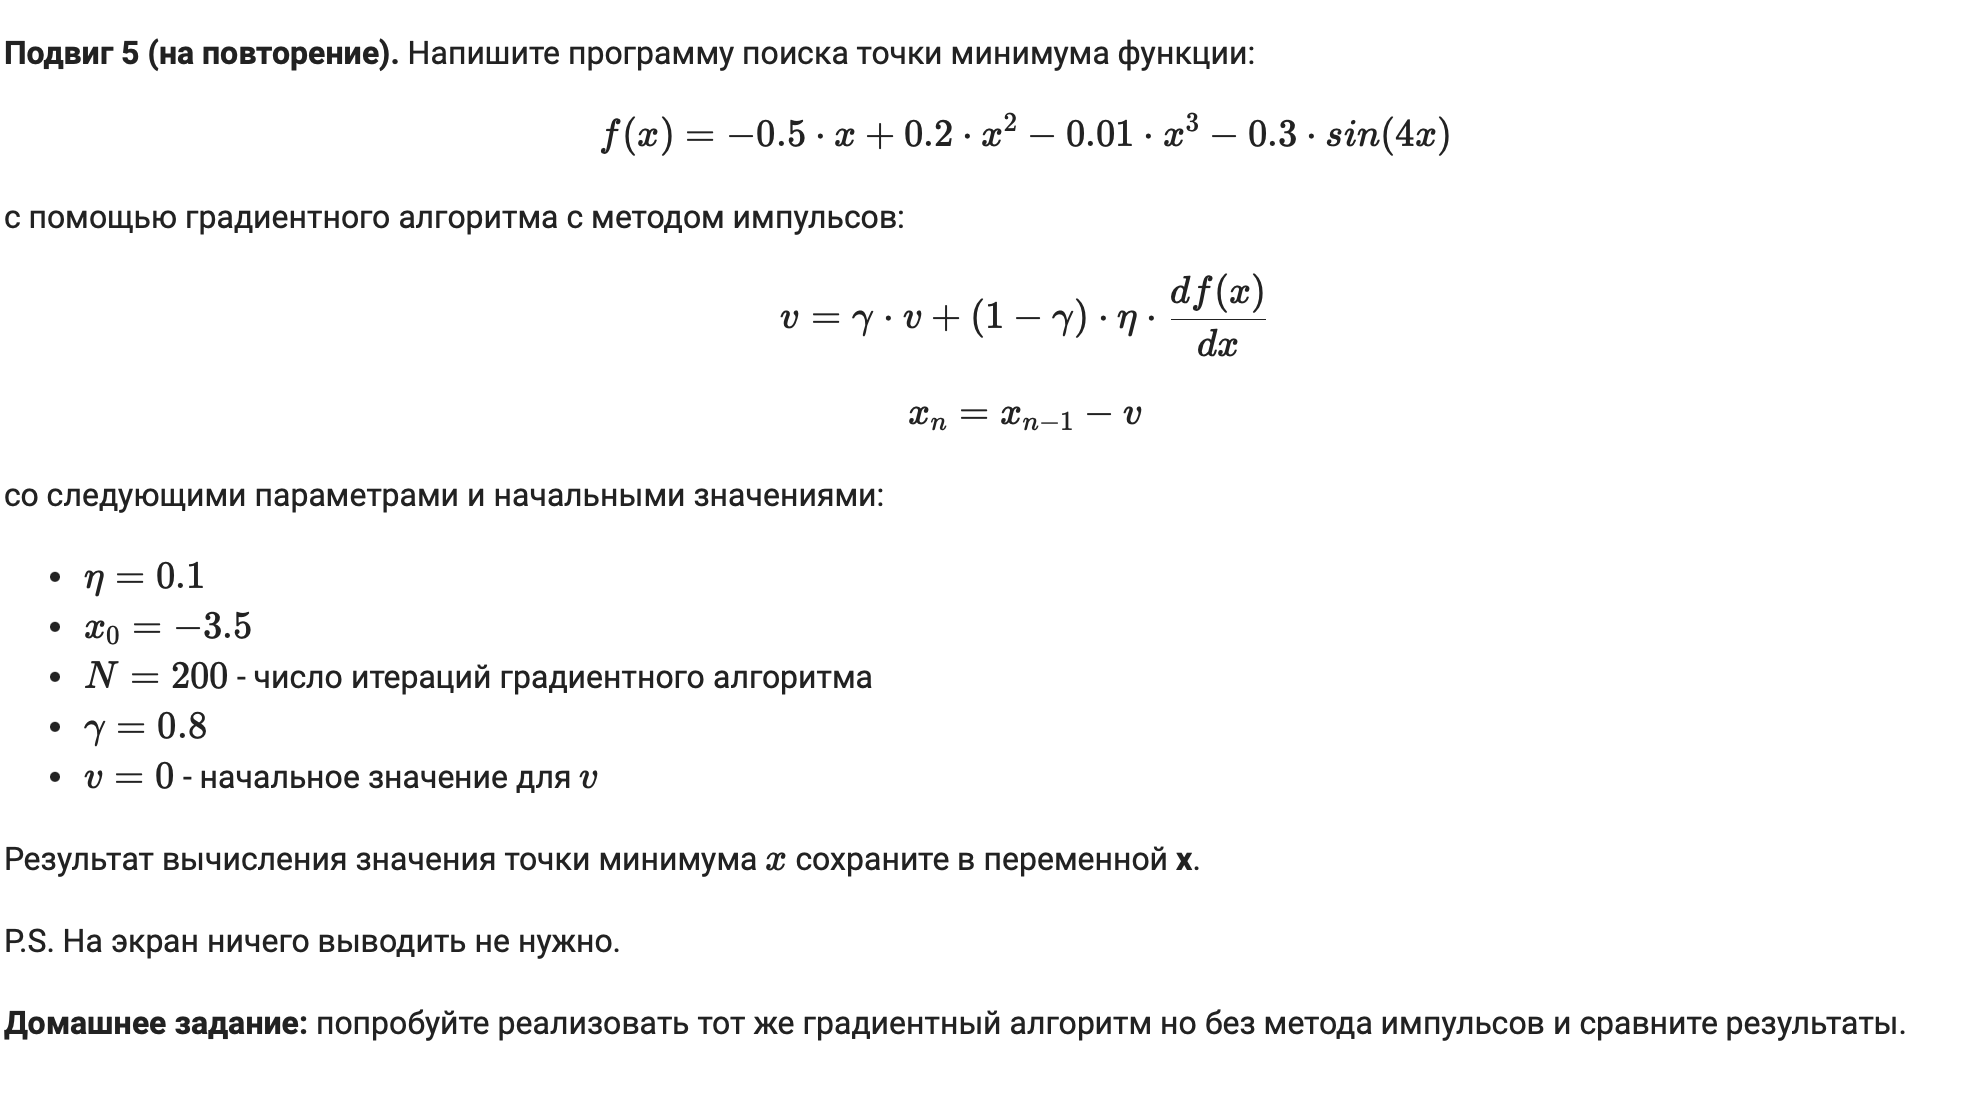

In [52]:
import numpy as np


def func(x):
    return -0.5 * x + 0.2 * x ** 2 - 0.01 * x ** 3 - 0.3 * np.sin(4*x)


# здесь объявляйте функцию df (производную) и продолжайте программу
def df(x):
    return -0.5 + 0.4 * x - 0.03 * x**2 - 1.2*np.cos(4*x)

nu = 0.1
x0 = -3.5
N = 200
gamma = 0.8
v = 0

for i in range(N):
    v = gamma * v + (1 - gamma) * nu * df(x0)
    x0 -= v
x = x0
x

np.float64(0.4606385324397492)

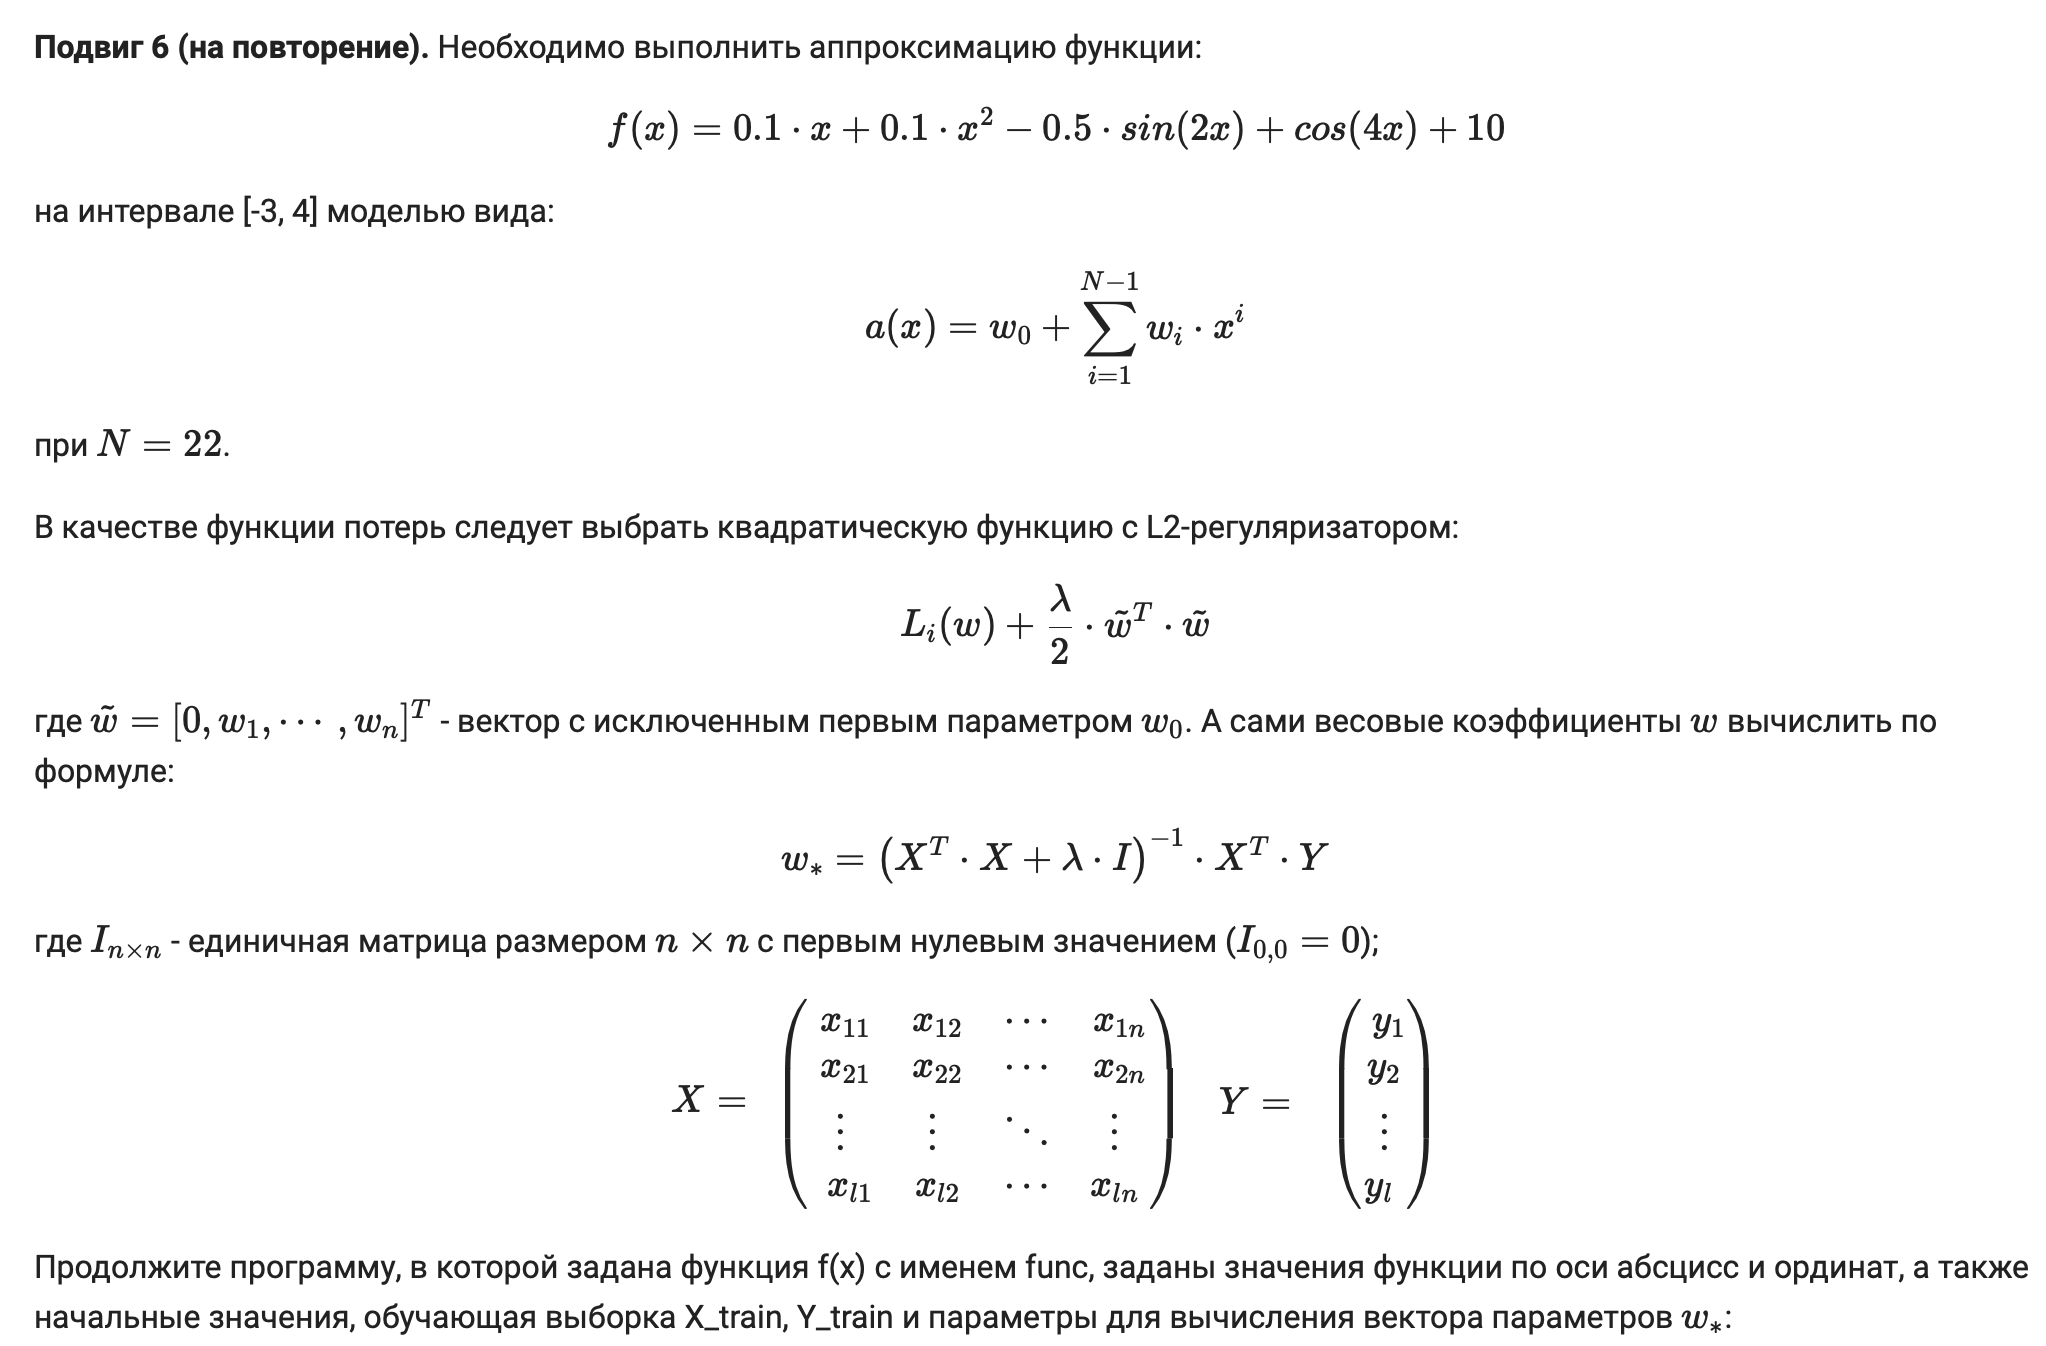
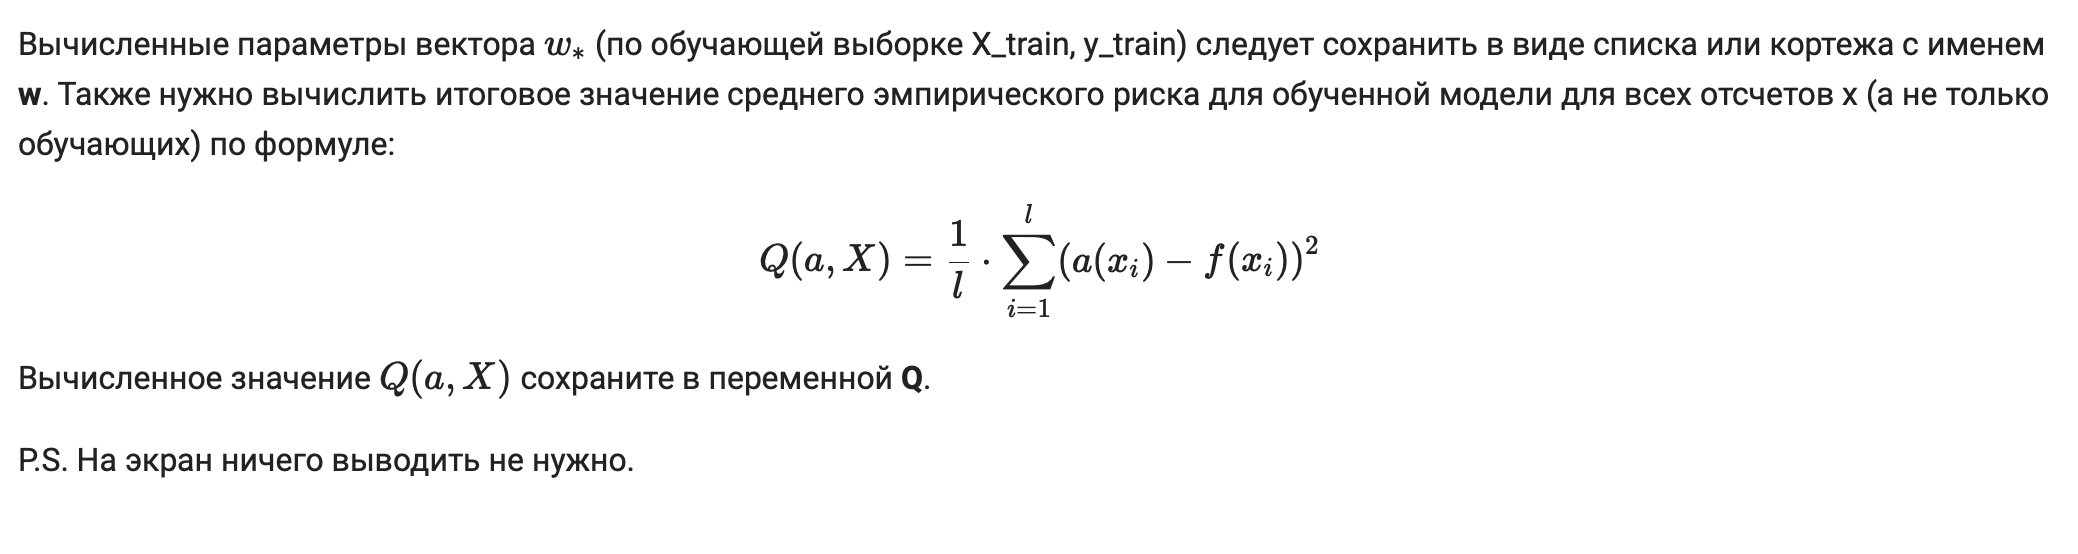

In [55]:
import numpy as np


def func(x):
    return 0.1 * x + 0.1 * x ** 2 - 0.5 * np.sin(2*x) + 1 * np.cos(4*x) + 10


x = np.arange(-3.0, 4.1, 0.1) # значения по оси абсцисс (Ox) с шагом 0,1
y = np.array(func(x)) # значения функции по оси ординат

N = 22  # размер признакового пространства (степень полинома N-1)
lm = 20  # параметр лямбда для L2-регуляризатора

X = np.array([[a ** n for n in range(N)] for a in x])  # матрица входных векторов
IL = np.array([[lm if i == j else 0 for j in range(N)] for i in range(N)])  # матрица lambda*I
IL[0][0] = 0  # первый коэффициент не регуляризуем

X_train = X[::2]  # обучающая выборка (входы)
Y_train = y[::2]  # обучающая выборка (целевые значения)

# здесь продолжайте программу

w = np.linalg.inv(X_train.T @ X_train + IL) @ X_train.T @ Y_train
Q = np.mean((X @ w - y) ** 2)
w, Q

(array([ 1.07808952e+01, -1.92799088e-01, -3.18785569e-01,  4.28551177e-03,
         1.02460735e-01,  3.79865631e-03,  1.24811403e-01,  1.66897589e-02,
         6.85183836e-02, -1.58843988e-02, -9.61037056e-02,  1.17033708e-02,
         3.30291459e-02, -4.17888434e-03, -5.42524652e-03,  7.57817079e-04,
         4.76152719e-04, -7.31357876e-05, -2.15724132e-05,  3.59524802e-06,
         3.97599362e-07, -7.09613277e-08]),
 np.float64(0.434781415608603))